# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["metric"] = pd.to_numeric(df["metric"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 45
Columns: ['commit', 'metric', 'status', 'description']


,commit,metric,status,description
0,fa114ea,1.222560,BASELINE,BASELINE — unmodified code
1,6aa45f4,1.229945,DISCARD,Increase MATRIX_LR from 0.04 to 0.05
2,3ec227f,1.220954,KEEP,Add LR warmup WARMUP_RATIO=0.05
3,43373d6,1.220425,KEEP,Increase WARMDOWN_RATIO from 0.5 to 0.6 and FI...
4,196a171,1.225149,DISCARD,Replace ReLU² with SwiGLU gated activation in MLP
5,399e6e0,1.217175,KEEP,Set WINDOW_PATTERN=SSSL (3 sliding-window + 1 ...
6,d6bee1d,1.214295,KEEP,Decrease MATRIX_LR from 0.04 to 0.03
7,c231b22,1.217966,DISCARD,Increase logit softcap from 15 to 30
8,d907481,1.215356,DISCARD,Increase EMBEDDING_LR from 0.6 to 0.8
9,1f122dd,1.214942,DISCARD,"Change WINDOW_PATTERN from SSSL to SSL (S,S,L,..."


In [18]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("keep", 0)
n_discard = counts.get("discard", 0)
n_crash = counts.get("crash", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD     34
KEEP        10
BASELINE     1


In [19]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["metric"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f} {desc}")

KEPT experiments (10 total):

  #  2  bpb=1.220954 Add LR warmup WARMUP_RATIO=0.05
  #  3  bpb=1.220425 Increase WARMDOWN_RATIO from 0.5 to 0.6 and FINAL_LR_FRAC from 0.0 to 0.05
  #  5  bpb=1.217175 Set WINDOW_PATTERN=SSSL (3 sliding-window + 1 full attention)
  #  6  bpb=1.214295 Decrease MATRIX_LR from 0.04 to 0.03
  # 11  bpb=1.179972 Halve TOTAL_BATCH_SIZE from 2**16 to 2**15 for more optimizer steps
  # 12  bpb=1.176485 Halve WEIGHT_DECAY from 0.2 to 0.1
  # 14  bpb=1.162423 Set ASPECT_RATIO=96 for wider model (384 dim, 3 heads) at DEPTH=4
  # 16  bpb=1.161688 Set EMBEDDING_LR=0.3 (lower from 0.6) for stability with wider 384-dim model
  # 17  bpb=1.161599 Halve WEIGHT_DECAY from 0.1 to 0.05
  # 40  bpb=1.161304 Set logit softcap=10 (down from 15) for tighter logit capping regularization


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

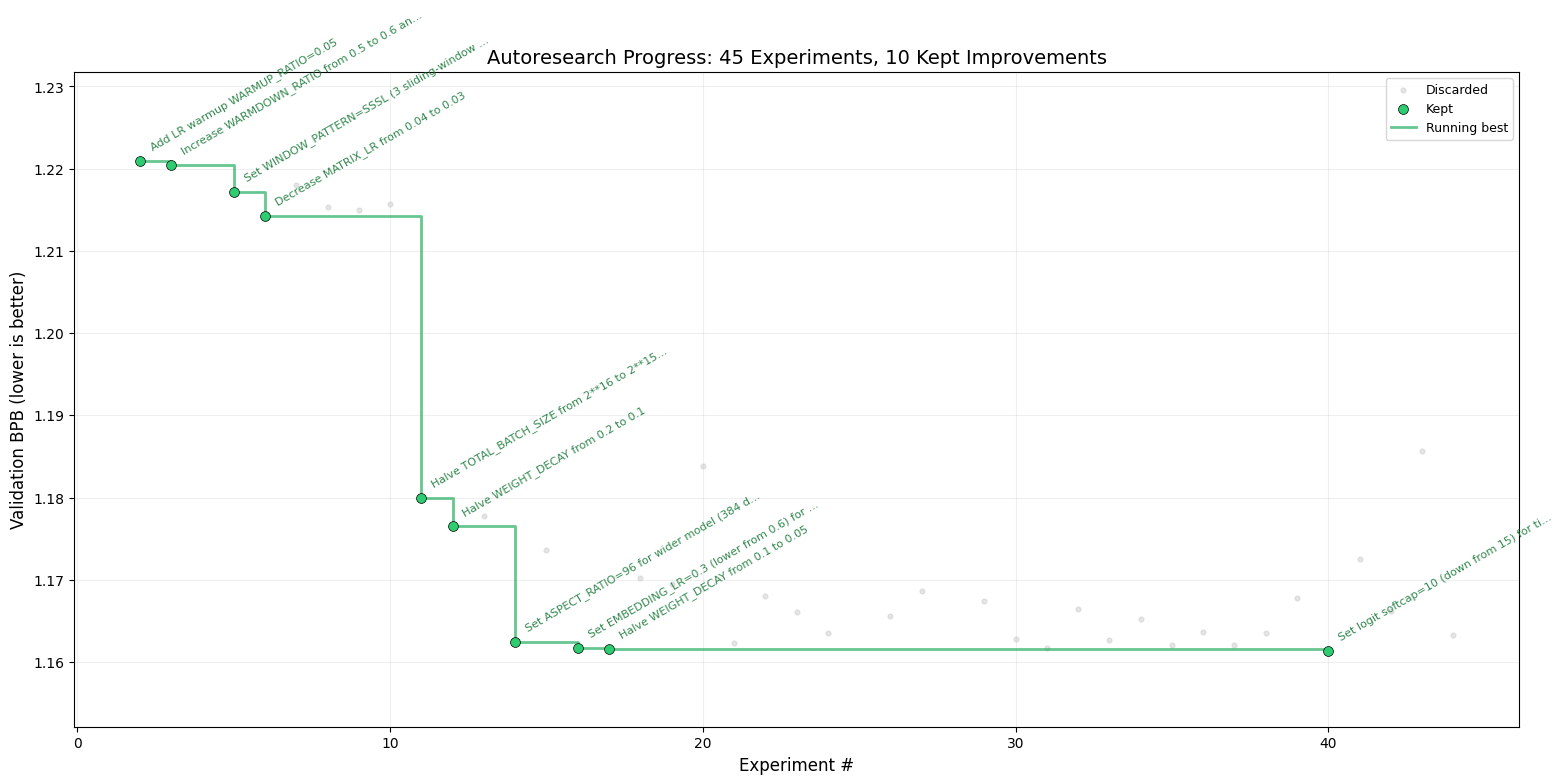

Saved to progress.png


In [20]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "metric"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["metric"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["metric"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["metric"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "metric"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [21]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["metric"]
best_bpb = kept["metric"].min()
best_row = kept.loc[kept["metric"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['metric']:.6f}  {desc}")

Baseline val_bpb:  1.222560
Best val_bpb:      1.161304
Total improvement: 0.061256 (5.01%)
Best experiment:   Set logit softcap=10 (down from 15) for tighter logit capping regularization

Cumulative effort per improvement:
  Experiment #  2: bpb=1.220954  Add LR warmup WARMUP_RATIO=0.05
  Experiment #  3: bpb=1.220425  Increase WARMDOWN_RATIO from 0.5 to 0.6 and FINAL_LR_FRAC from 0.0 to 0.05
  Experiment #  5: bpb=1.217175  Set WINDOW_PATTERN=SSSL (3 sliding-window + 1 full attention)
  Experiment #  6: bpb=1.214295  Decrease MATRIX_LR from 0.04 to 0.03
  Experiment # 11: bpb=1.179972  Halve TOTAL_BATCH_SIZE from 2**16 to 2**15 for more optimizer steps
  Experiment # 12: bpb=1.176485  Halve WEIGHT_DECAY from 0.2 to 0.1
  Experiment # 14: bpb=1.162423  Set ASPECT_RATIO=96 for wider model (384 dim, 3 heads) at DEPTH=4
  Experiment # 16: bpb=1.161688  Set EMBEDDING_LR=0.3 (lower from 0.6) for stability with wider 384-dim model
  Experiment # 17: bpb=1.161599  Halve WEIGHT_DECAY from 0.1

## Top Hits (Kept Experiments by Improvement)

In [22]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["metric"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["metric"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['metric']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.034323  1.179972  Halve TOTAL_BATCH_SIZE from 2**16 to 2**15 for more optimizer steps
   2  +0.014062  1.162423  Set ASPECT_RATIO=96 for wider model (384 dim, 3 heads) at DEPTH=4
   3  +0.003487  1.176485  Halve WEIGHT_DECAY from 0.2 to 0.1
   4  +0.003250  1.217175  Set WINDOW_PATTERN=SSSL (3 sliding-window + 1 full attention)
   5  +0.002880  1.214295  Decrease MATRIX_LR from 0.04 to 0.03
   6  +0.000735  1.161688  Set EMBEDDING_LR=0.3 (lower from 0.6) for stability with wider 384-dim model
   7  +0.000529  1.220425  Increase WARMDOWN_RATIO from 0.5 to 0.6 and FINAL_LR_FRAC from 0.0 to 0.05
   8  +0.000295  1.161304  Set logit softcap=10 (down from 15) for tighter logit capping regularization
   9  +0.000089  1.161599  Halve WEIGHT_DECAY from 0.1 to 0.05

      +0.059650              TOTAL improvement over baseline
